# DNN Evaluation (PyTorch)

<div style="text-align: justify">

The following notebook evaluates the deep neural network classifier trained in <b>05b_dnn_training</b>. It consumes the persisted model checkpoint and test-set predictions produced by the training pipeline and generates a comprehensive suite of quality metrics and visualisations.

Two split strategies are supported, mirroring those of the training notebook:

* <b>train_test</b> — evaluation on the held-out 20 % test set.
* <b>k_fold</b> — evaluation on the concatenated out-of-fold (OOF) predictions covering the full dataset.

</div>

## Pipeline Summary

| Step | Module | Description |
|------|--------|-------------|
| Config | `hydra.compose` | Load analysis and model configuration |
| MLflow | `mlflow` | Resume training run and log evaluation metrics |
| Load | `dnn.load_model`, `io.load_dataframe` | Load persisted model(s) and predictions parquet |
| Labels | — | Derive ordered class names and display labels from config |
| Permutation Importance | `evaluate.plot_permutation_importance` | Model-agnostic permutation-based importance |
| SHAP | `evaluate.compute_dnn_shap_values`, `evaluate.plot_shap_importance` | SHAP multiclass feature attribution (GradientExplainer) |
| Summary Metrics | `evaluate.compute_summary_metrics` | Accuracy, F1, per-class AUC |
| Classification Report | `evaluate.plot_classification_report` | Per-class precision, recall, F1-score |
| Confusion Matrix | `evaluate.plot_confusion_matrix` | Row-normalised confusion matrix |
| ROC Curves | `evaluate.plot_roc_curves` | Per-class one-vs-rest ROC curves |
| PR Curves | `evaluate.plot_pr_curves` | Per-class precision-recall curves |
| Score Distributions | `evaluate.plot_score_distributions` | Classifier output distributions per class |
| Save | `visualization.plots.save_figure` | Persist all plots to disk and log to MLflow |

The same pipeline is available as a CLI via `python run.py stage=evaluate model=dnn` or `make evaluate-dnn`.

## Initialization

### Libraries

Configuration:
* [Hydra](https://hydra.cc/)
* [OmegaConf](https://omegaconf.readthedocs.io/)
* [pyrootutils](https://github.com/ashleve/pyrootutils)

Data Processing:
* [Pandas](https://pandas.pydata.org/)
* [NumPy](https://numpy.org/)

Data Visualization:
* [Atlas MPL Style](https://atlas-mpl.readthedocs.io/en/latest/styles.html)
* [Matplotlib](https://matplotlib.org/)
* [Seaborn](https://seaborn.pydata.org/)

Machine Learning:
* [PyTorch](https://pytorch.org/)
* [scikit-learn](https://scikit-learn.org/stable/)
* [SHAP](https://shap.readthedocs.io/en/latest/)

Experiment Tracking:
* [MLflow](https://mlflow.org/)

Serialization:
* [Apache Parquet](https://parquet.apache.org/)

### Notebook

Activating autoreload of imported modules.

In [1]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

Initializing the project root.

In [2]:
import pyrootutils

path = pyrootutils.setup_root(
    search_from=__file__ if "__file__" in locals() else ".",
    indicator=".gitignore",
    pythonpath=True,
)

Suppressing unessential warnings and applying ATLAS style.

In [3]:
from src.utils import suppress_warnings
from src.visualization.plots import apply_atlas_style

suppress_warnings()
apply_atlas_style()

## Configuration

Loading the Hydra configuration with the DNN model config override. The split strategy and all path parameters must match those used during training.

In [4]:
from hydra import compose, initialize_config_dir

initialize_config_dir(config_dir=str(path / "configs"), version_base="1.3")
cfg = compose(config_name="config", overrides=["model=dnn"])

## MLflow

Resuming the most recent DNN training run so that evaluation metrics and artifacts are logged to the same run.

In [5]:
import logging

import mlflow

logging.getLogger("mlflow").setLevel(logging.WARNING)
logging.getLogger("alembic").setLevel(logging.WARNING)

tracking_uri = f"file://{path}/mlruns"
mlflow.set_tracking_uri(tracking_uri)

experiment_name = cfg.get("experiment_name", "tau-supersymmetry-search-dnn")
client = mlflow.tracking.MlflowClient(tracking_uri=tracking_uri)
experiment = client.get_experiment_by_name(experiment_name)

latest_runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["start_time DESC"],
    max_results=1,
)
run_id = latest_runs[0].info.run_id
run = mlflow.start_run(run_id=run_id)

print(f"Resumed MLflow run ID: {run_id}")

Resumed MLflow run ID: c04c0d80bbe6472ba5be3b83e9281179


## Deserialization

Resolving input and output directories from config.

In [6]:
from src.processing.analysis import get_output_paths

output_paths = get_output_paths(cfg)
dataframes_dir = path / output_paths["dataframes_dir"]
models_dir = path / output_paths["models_dir"]
plots_dir = path / output_paths["plots_dir"] / "dnn_evaluation"

plots_dir.mkdir(parents=True, exist_ok=True)

Deriving ordered class names and display labels from `eventOrigin`.

In [7]:
from omegaconf import OmegaConf
from src.eda.utils import get_class_names, get_class_labels
from src.processing.io import load_dataframe

df_mc = load_dataframe(dataframes_dir / "mc.parquet")

display_labels = OmegaConf.to_container(cfg.merge.display_labels, resolve=True)
class_names = get_class_names(df_mc)
class_labels = get_class_labels(df_mc, display_labels=display_labels)
n_classes = len(class_names)

print(f"Classes ({n_classes}): {class_names}")
class_labels

Classes (6): ['topquarks', 'wtaunu', 'ztautau', 'diboson', 'other', 'signal']


['top quarks',
 '$W \\rightarrow \\tau\\nu$',
 '$Z \\rightarrow \\tau\\tau$',
 'diboson',
 'other',
 'signal']

Loading the trained model(s) and scaler(s) from disk.

In [8]:
from src.models.dnn import load_model, resolve_device

device = resolve_device()
split_strategy = cfg.pipeline.split_strategy

if split_strategy == "train_test":
    model, scaler = load_model(models_dir / "dnn.pt", device=device)
    print(f"Loaded model on {device}")
    print(model)

elif split_strategy == "k_fold":
    import re
    fold_paths = sorted(
        models_dir.glob("dnn_fold*.pt"),
        key=lambda p: int(re.search(r"\d+", p.stem).group()),
    )
    models_scalers = [load_model(p, device=device) for p in fold_paths]
    models = [ms[0] for ms in models_scalers]
    scalers = [ms[1] for ms in models_scalers]
    print(f"Loaded {len(models)} fold models")

Loaded model on cuda
DNNClassifier(
  (backbone): Sequential(
    (0): Linear(in_features=53, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=128, out_features=128, bias=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=128, out_features=128, bias=True)
    (13): ReLU()
    (14): Dropout(p=0.2, inplace=False)
  )
  (head): Linear(in_features=128, out_features=6, bias=True)
)


Loading the test-set predictions produced by the training pipeline.

In [9]:
import numpy as np

predictions_df = load_dataframe(dataframes_dir / "dnn_predictions.parquet")

y_true = predictions_df["y_true"].to_numpy()
y_pred = predictions_df["y_pred"].to_numpy()
y_proba = predictions_df[[f"p_{name}" for name in class_names]].to_numpy()

print(f"Predictions loaded: {len(predictions_df):,} events")
predictions_df.head()

Predictions loaded: 1,965,434 events


,y_true,y_pred,p_topquarks,p_wtaunu,p_ztautau,p_diboson,p_other,p_signal
0,5,5,0.001680,0.000316,0.000175,0.002053,0.009405,0.986370
1,5,5,0.002431,0.003198,0.007738,0.012804,0.005957,0.967873
2,3,3,0.079059,0.316727,0.084642,0.507352,0.010638,0.001582
3,2,1,0.022299,0.411391,0.317364,0.218556,0.020077,0.010312
4,0,0,0.558660,0.020476,0.010899,0.069529,0.318990,0.021446


## Feature Importance

### Permutation Importance

Model-agnostic permutation importance, computed on a subsample for speed.

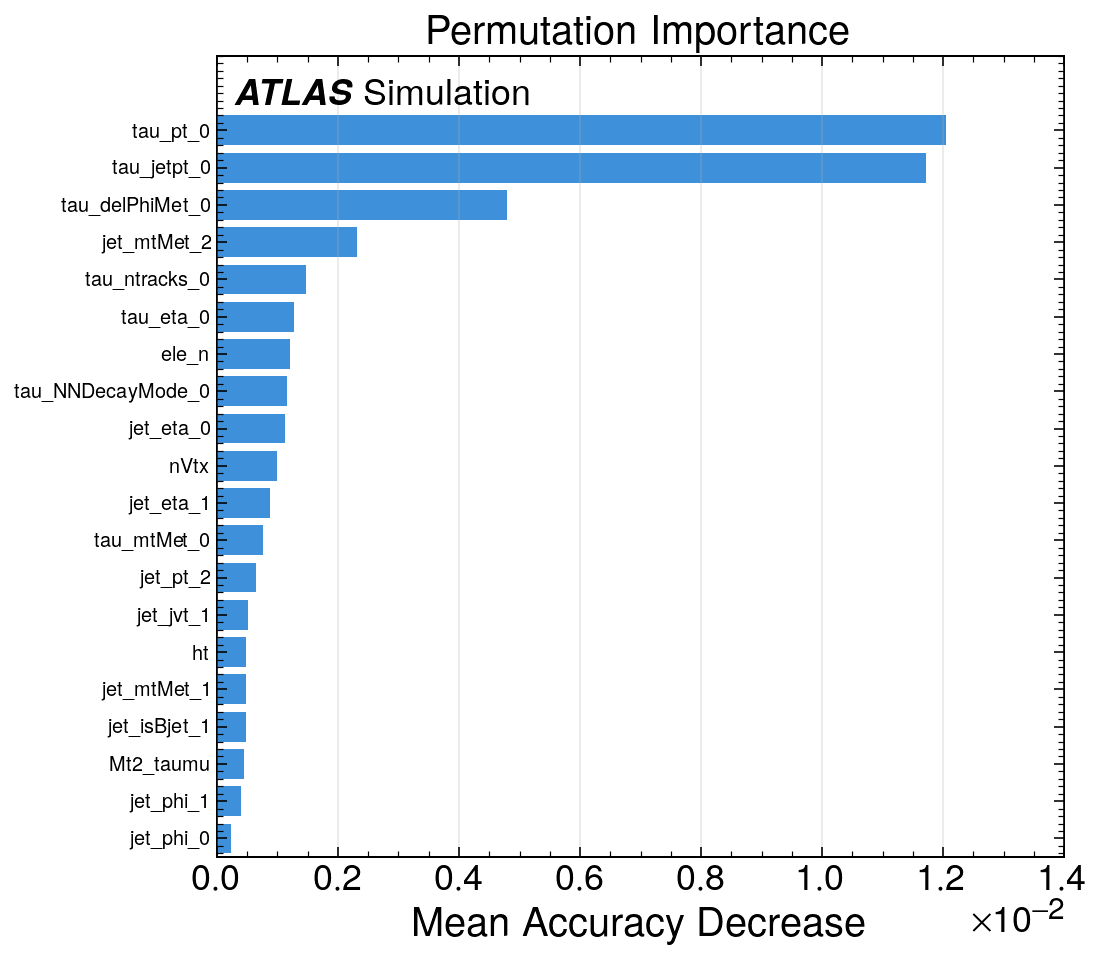

In [10]:
from src.models.evaluation import plot_permutation_importance
from src.models.splits import prepare_features_target
from src.visualization.plots import save_figure

X, _, _ = prepare_features_target(df_mc)
feature_names = X.columns.tolist()

perm_model = model if split_strategy == "train_test" else models[0]
perm_scaler = scaler if split_strategy == "train_test" else scalers[0]

fig = plot_permutation_importance(
    perm_model, X, y_true, perm_scaler, device,
    feature_names=feature_names, n_features=20, seed=cfg.seed,
)
fi_path = plots_dir / "permutation_importance.png"
save_figure(fig, fi_path)
mlflow.log_artifact(str(fi_path))
fig.show()

### SHAP Values

Per-class SHAP feature attributions via GradientExplainer, showing the top 20 features.

In [11]:
from src.models.evaluation import compute_dnn_shap_values, plot_shap_importance

shap_model = model if split_strategy == "train_test" else models[0]
shap_scaler = scaler if split_strategy == "train_test" else scalers[0]

shap_values, X_sample = compute_dnn_shap_values(
    shap_model, X, shap_scaler, device, n_samples=200, seed=cfg.seed,
)
print(f"SHAP values computed on {len(X_sample):,} events")

SHAP values computed on 200 events


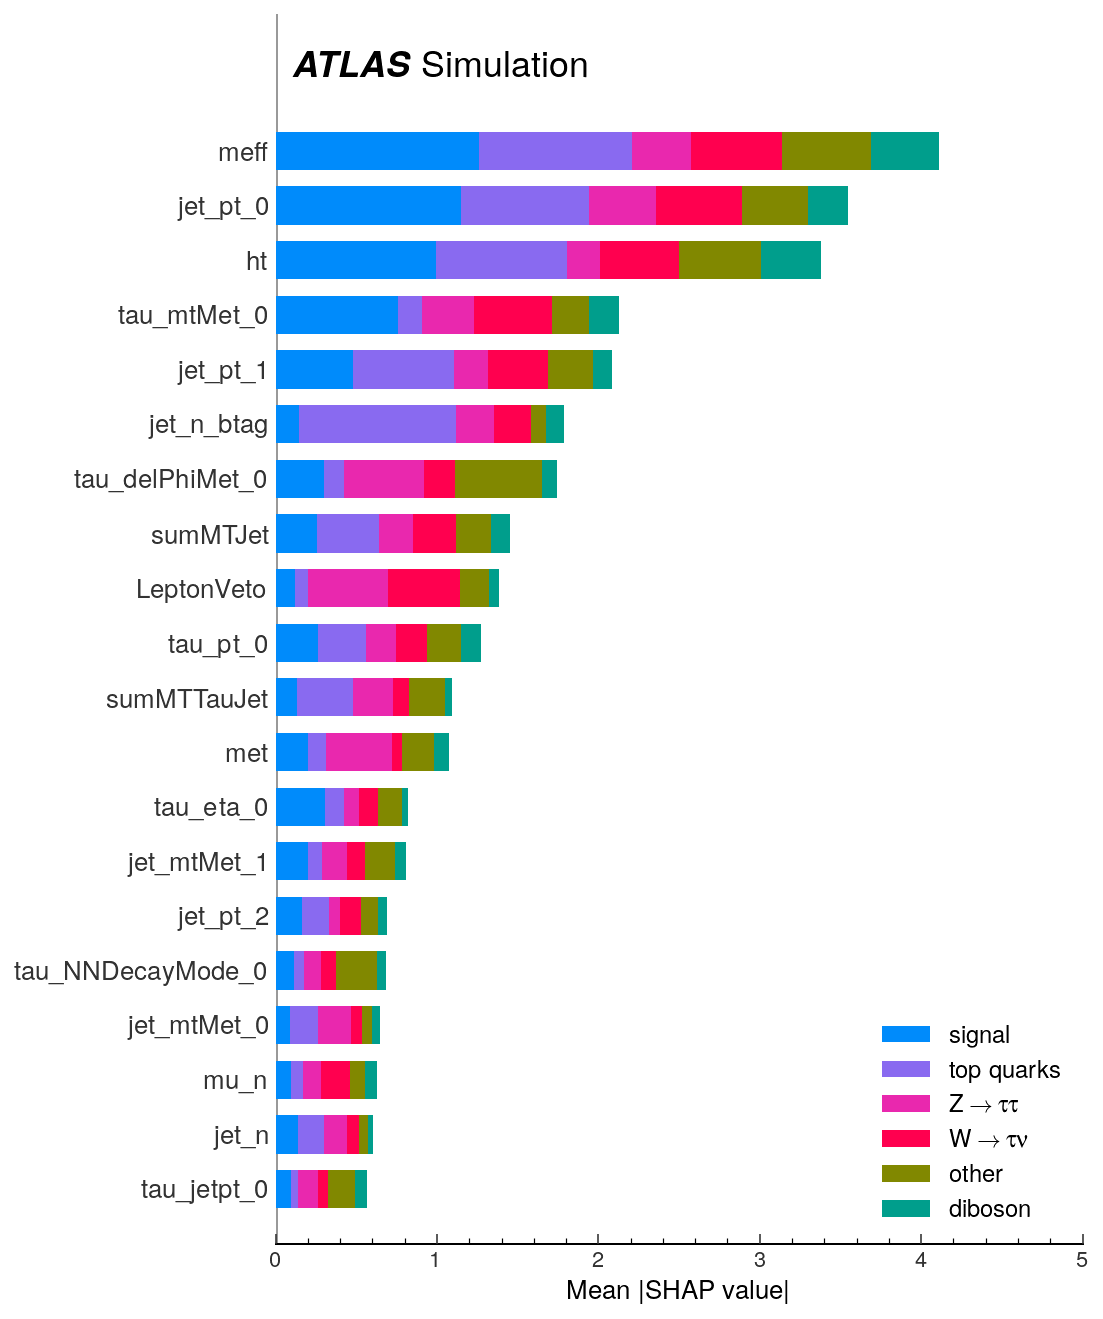

In [12]:
fig = plot_shap_importance(shap_values, X_sample, class_labels=class_labels, n_features=20)
shap_path = plots_dir / "shap_importance.png"
save_figure(fig, shap_path)
mlflow.log_artifact(str(shap_path))
fig.show()

## Classification Metrics

### Summary Metrics

Overall accuracy, macro and weighted F1-score, macro one-vs-rest AUC, and per-class AUC. All values are logged to the active MLflow run.

In [13]:
import pandas as pd
from src.models.evaluation import compute_summary_metrics

metrics = compute_summary_metrics(y_true, y_pred, y_proba, class_names)
mlflow.log_metrics(metrics)

summary = pd.Series(metrics).rename("value").to_frame()
summary["value"] = summary["value"].map("{:.4f}".format)
print(summary.to_string())

                value
accuracy       0.6343
f1_macro       0.6224
f1_weighted    0.6281
roc_auc_macro  0.9024
auc_topquarks  0.9469
auc_wtaunu     0.8781
auc_ztautau    0.9064
auc_diboson    0.7835
auc_other      0.9289
auc_signal     0.9709


### Classification Report

Per-class precision, recall, and F1-score heatmap with support counts.

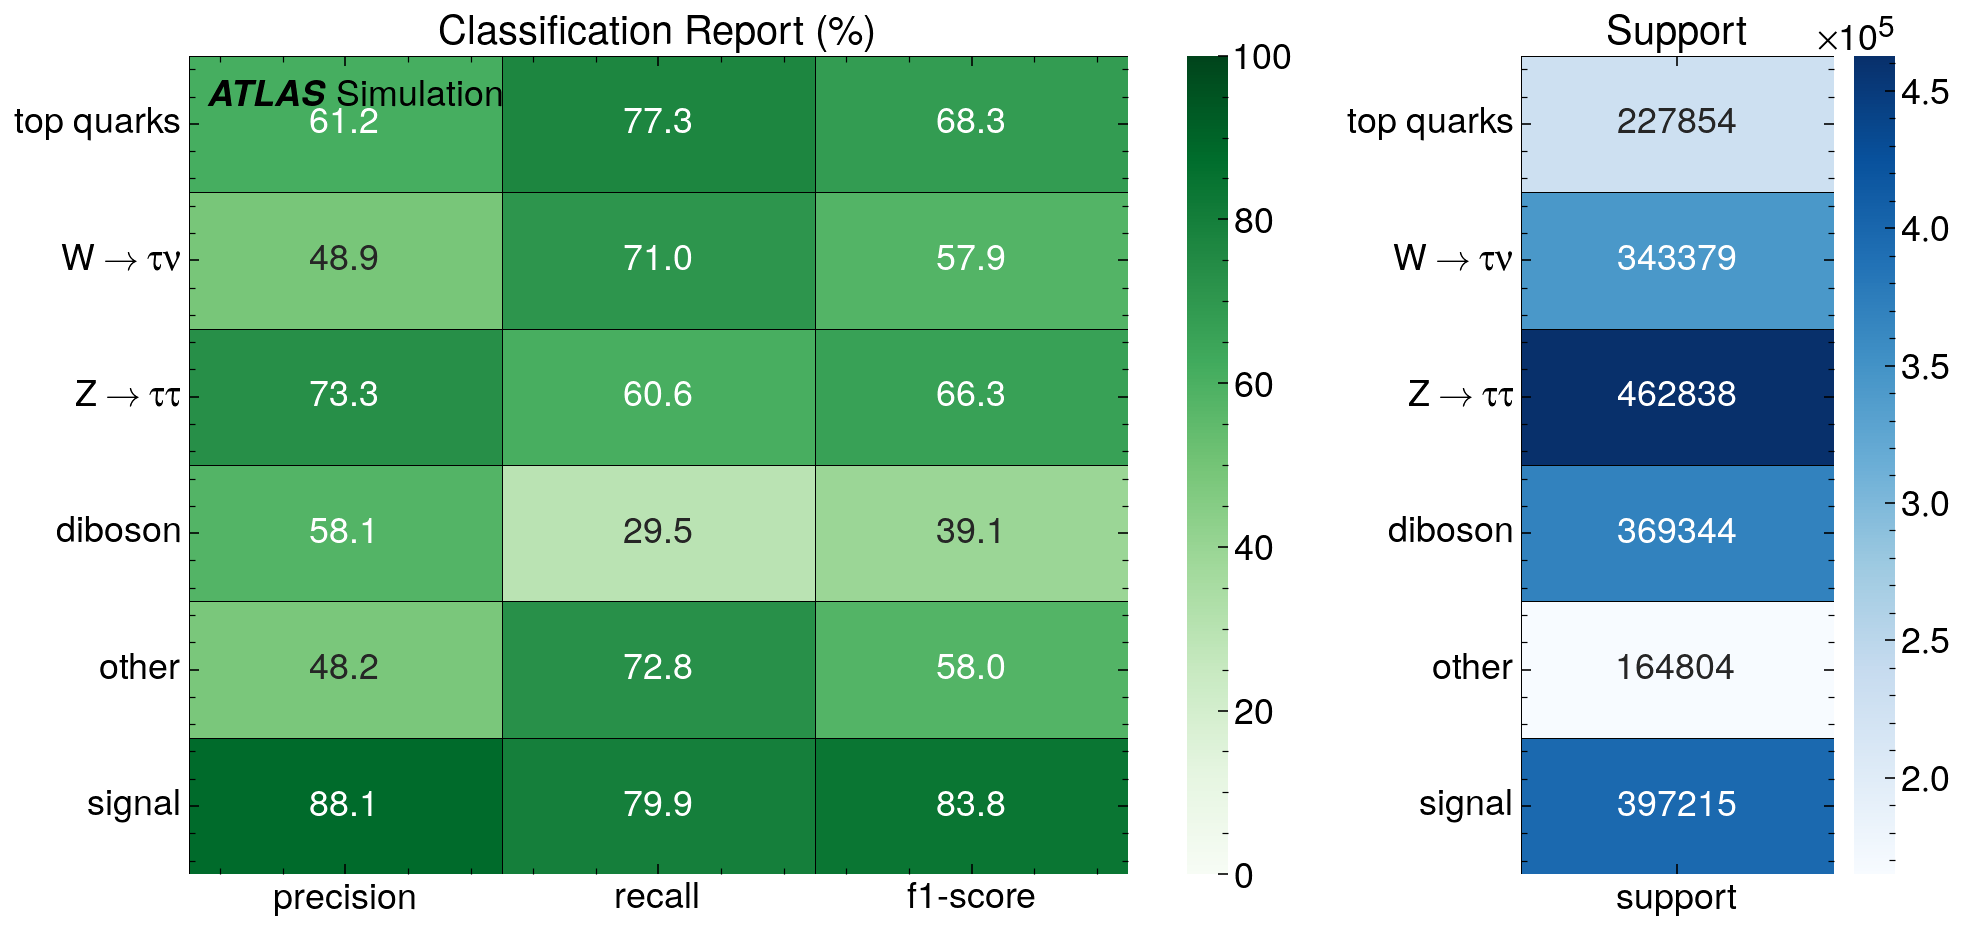

In [14]:
from src.models.evaluation import plot_classification_report

fig = plot_classification_report(y_true, y_pred, class_labels=class_labels)
cr_path = plots_dir / "classification_report.png"
save_figure(fig, cr_path)
mlflow.log_artifact(str(cr_path))
fig.show()

### Confusion Matrix

Row-normalised confusion matrix with absolute counts and per-class recall percentages.

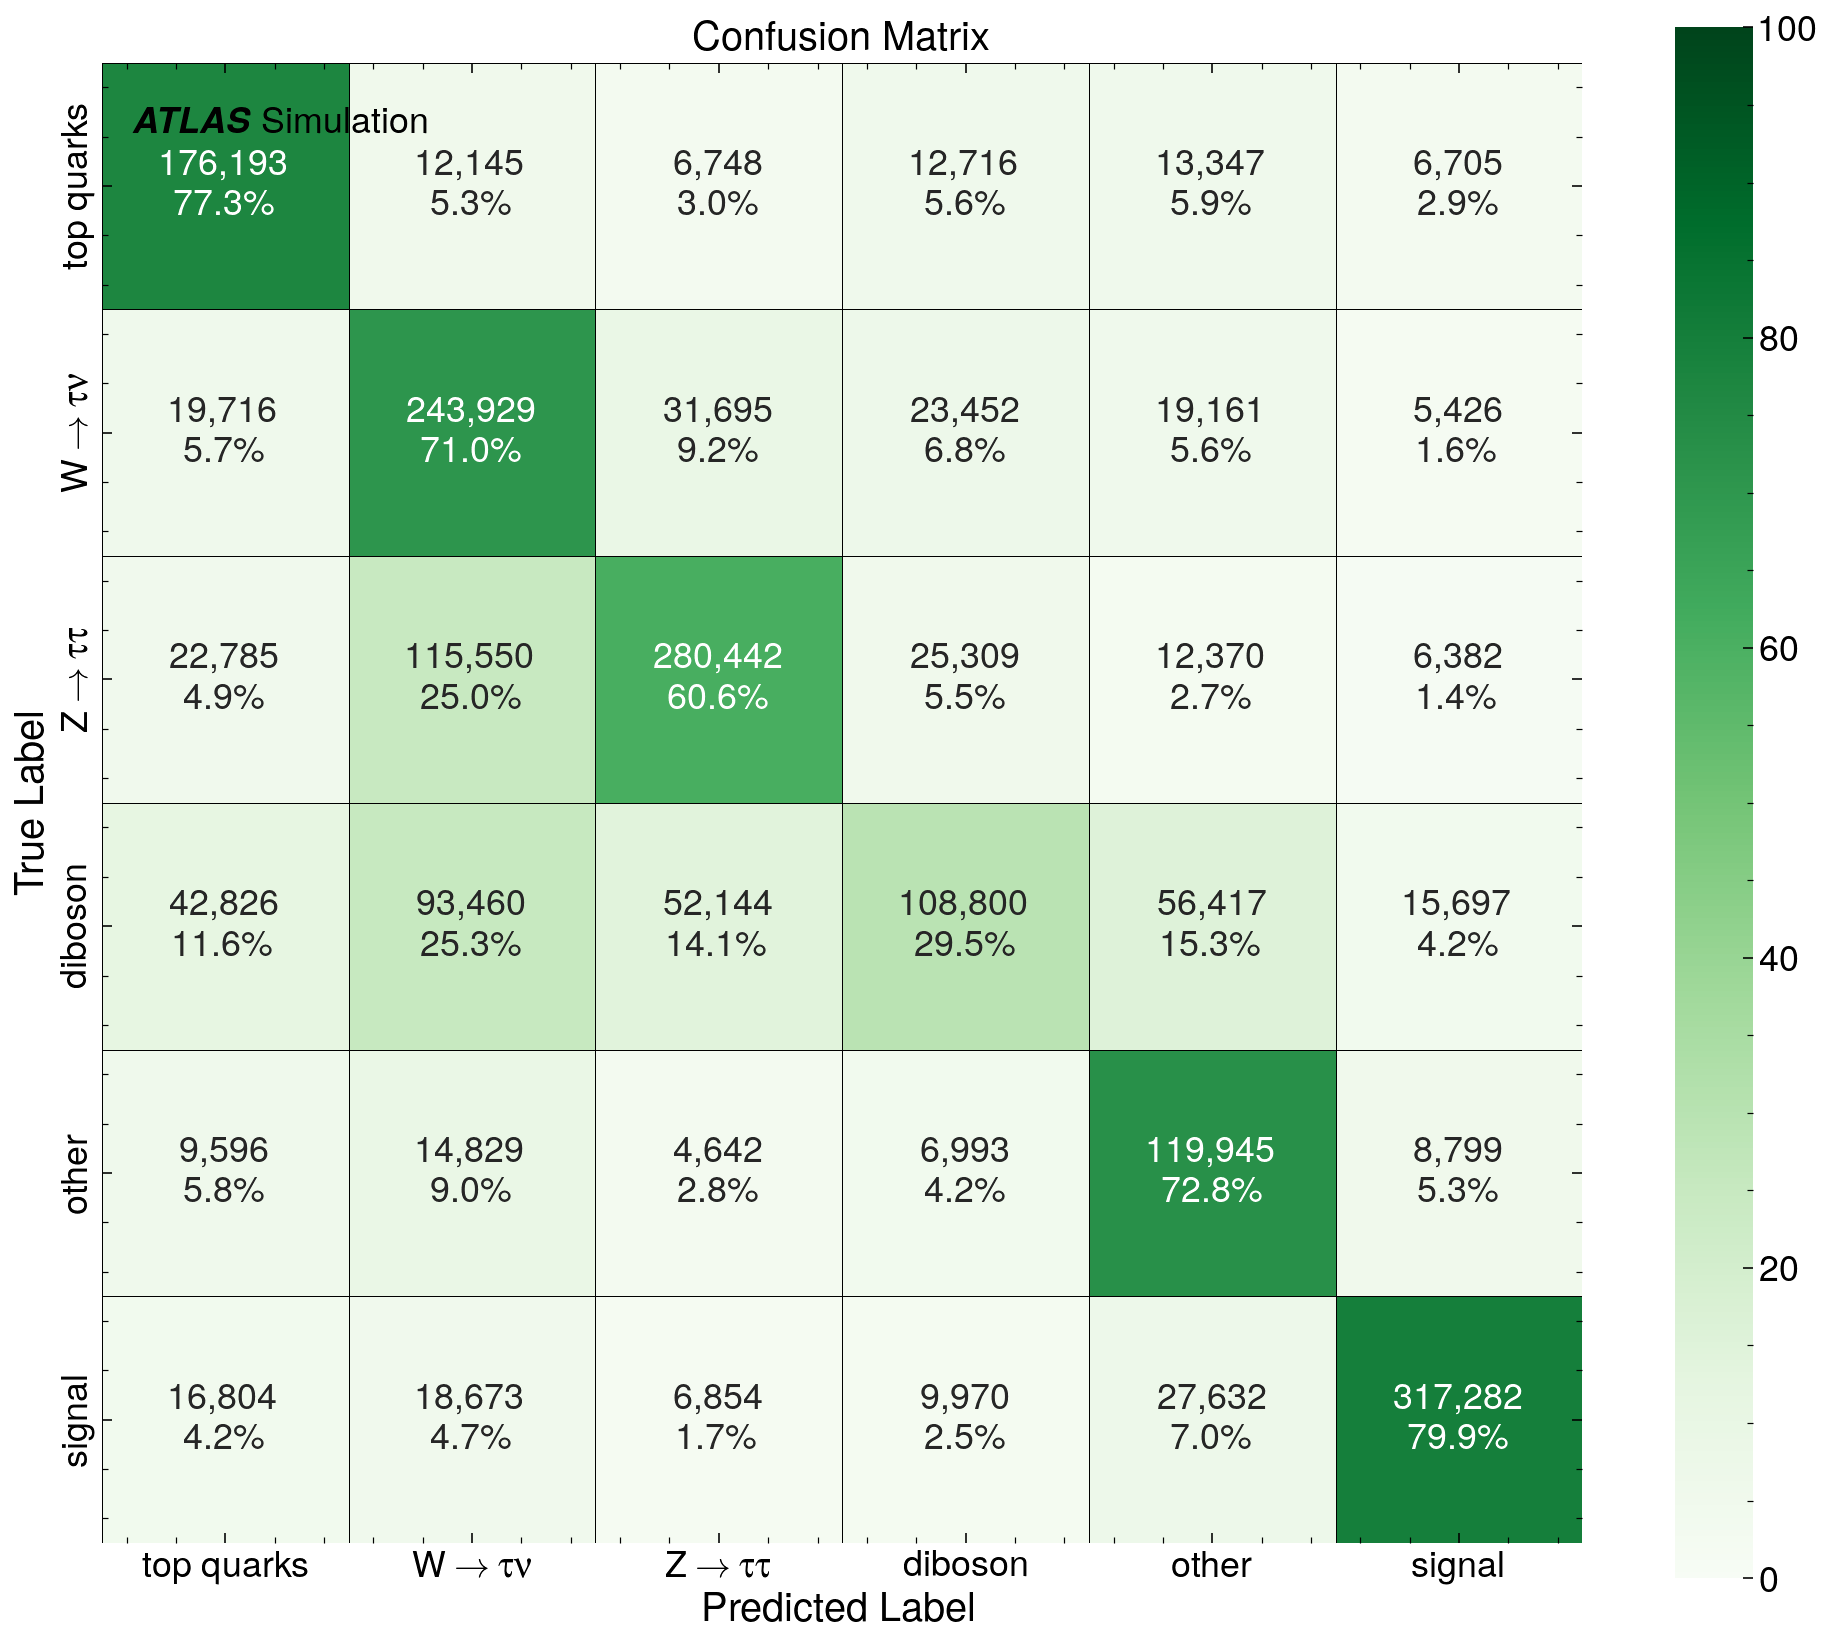

In [15]:
from src.models.evaluation import plot_confusion_matrix

fig = plot_confusion_matrix(y_true, y_pred, class_labels=class_labels)
cm_path = plots_dir / "confusion_matrix.png"
save_figure(fig, cm_path)
mlflow.log_artifact(str(cm_path))
fig.show()

## Curves

### ROC Curves

Per-class one-vs-rest ROC curves with AUC values.

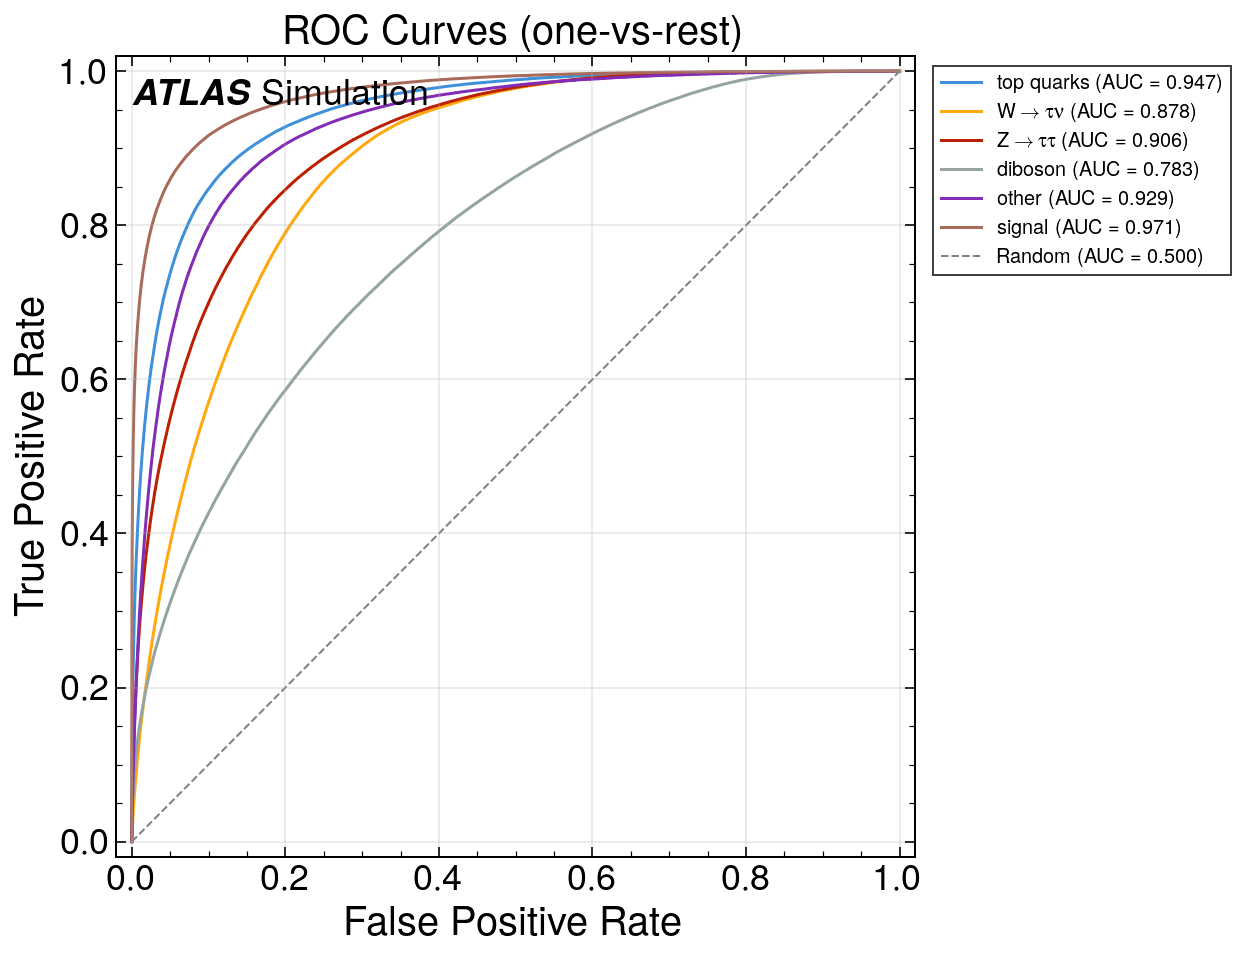

In [16]:
from src.models.evaluation import plot_roc_curves

fig = plot_roc_curves(y_true, y_proba, class_labels=class_labels)
roc_path = plots_dir / "roc_curves.png"
save_figure(fig, roc_path)
mlflow.log_artifact(str(roc_path))
fig.show()

### Precision-Recall Curves

Per-class one-vs-rest precision-recall curves with average precision (AP) values.

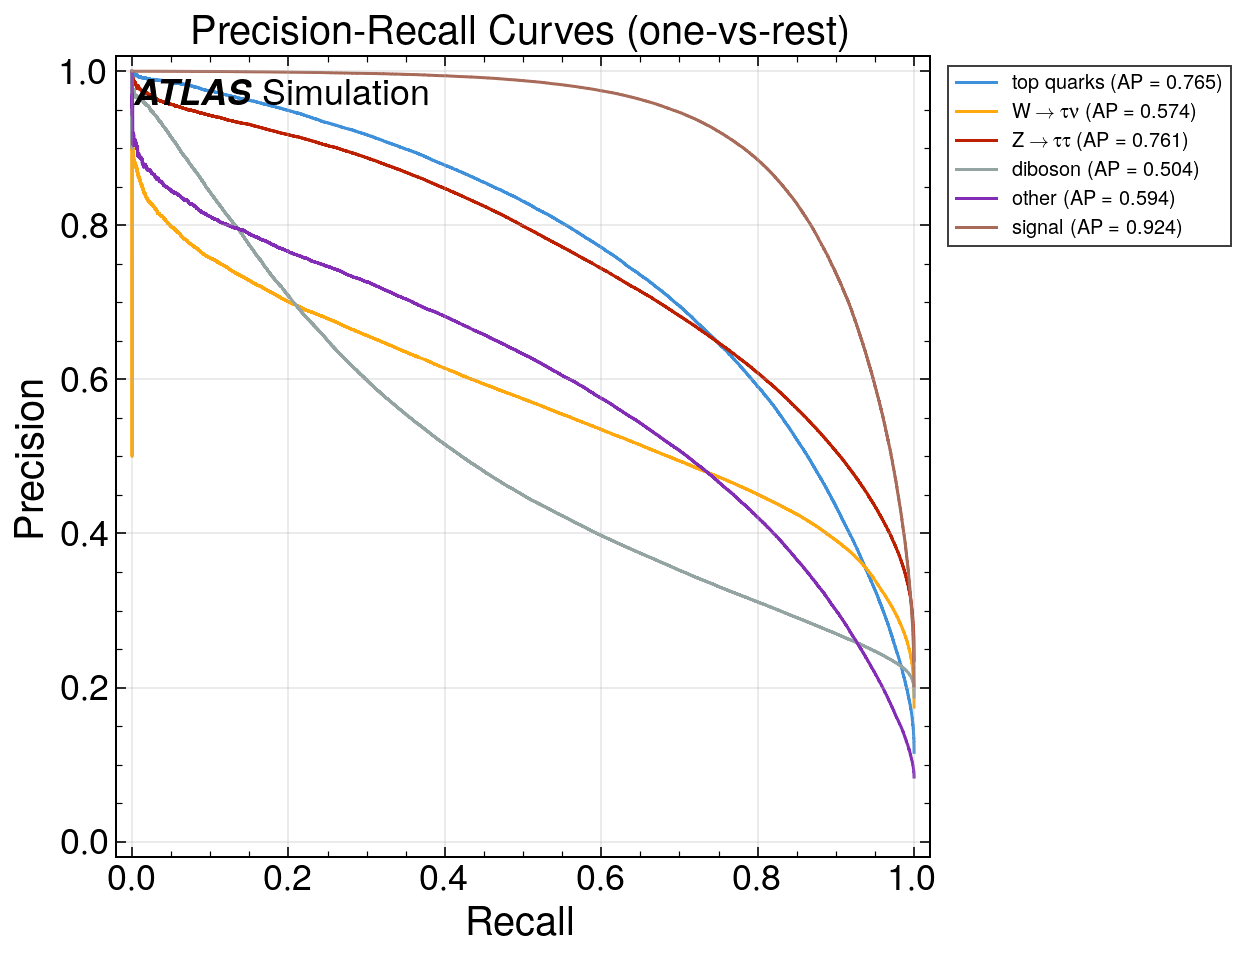

In [17]:
from src.models.evaluation import plot_pr_curves

fig = plot_pr_curves(y_true, y_proba, class_labels=class_labels)
pr_path = plots_dir / "pr_curves.png"
save_figure(fig, pr_path)
mlflow.log_artifact(str(pr_path))
fig.show()

## Score Distributions

Per-class normalised distributions of the classifier's predicted probability, shown separately for each true class.

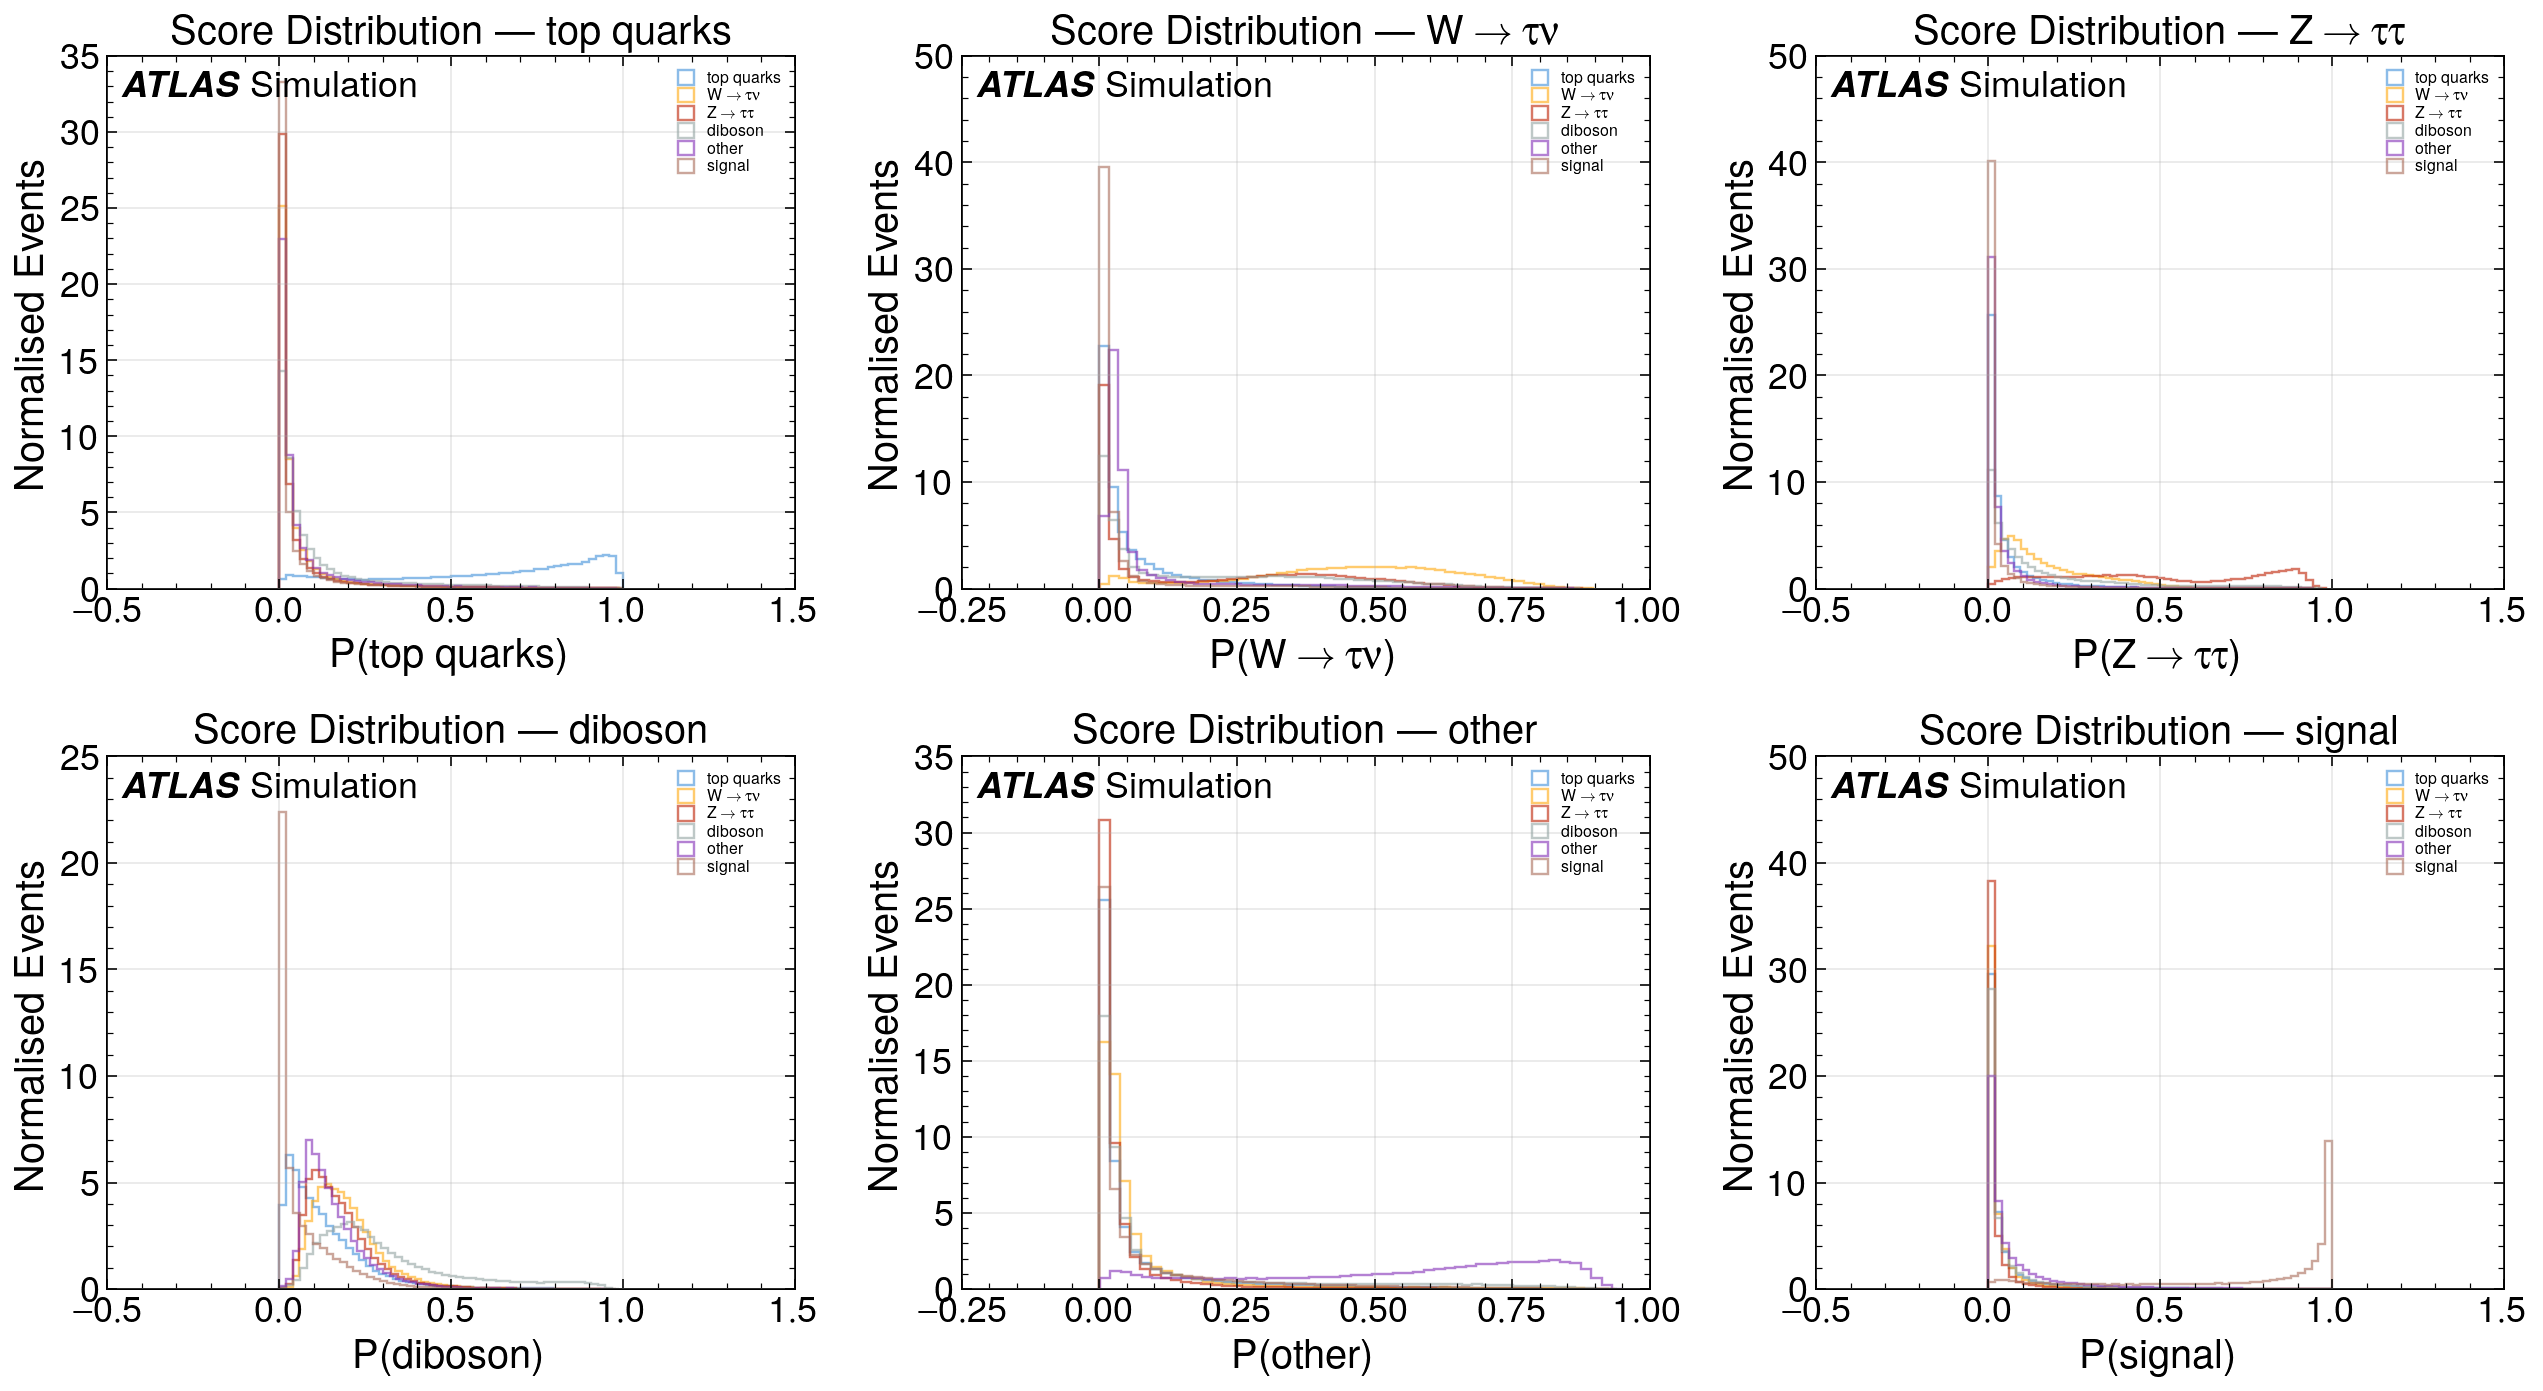

In [18]:
from src.models.evaluation import plot_score_distributions

fig = plot_score_distributions(y_true, y_proba, class_labels=class_labels, bins=50)
sd_path = plots_dir / "score_distributions.png"
save_figure(fig, sd_path)
mlflow.log_artifact(str(sd_path))
fig.show()

## Serialization

Closing the MLflow run. All metrics and artifacts have been logged to the resumed training run.

In [19]:
mlflow.end_run()
print(f"MLflow run {run_id} closed.")

MLflow run c04c0d80bbe6472ba5be3b83e9281179 closed.
